## Run a pipeline adding a custom algorithm

This process will run the entire pipeline described in a configuration file and will add a custom algorithm to it

## Import dependencies

In [16]:
%load_ext autoreload
%autoreload 2
from paidiverpy.pipeline import Pipeline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Instantiate the Pipeline class

When you instantiate the pipeline class, it will install some dependencies described in the configuration file that are necessary for the custom algorithm

In [17]:
pipeline = Pipeline(config_file_path="../config_files/config_custom_algorithm.yml")

This occurs because of the following step that you added in the conf file:

```
steps:
    ...

  - custom:
      name: "min_max_data"
      file_path: "/mnt/noc/code/paidiver/paidiverpy/examples/custom_algorithms/custom_algorithm_example.py"
      class_name: "MyMethod"
      dependencies:
        - "scikit-learn"
      params:
        feature_range: (0, 1)
```

In this case, you are saying that you need to install scikit-learn to use the custom algorithm

In [18]:
pipeline.config

{
    "general": {
        "name": "raw",
        "step_name": "open",
        "sample_data": "benthic_csv",
        "input_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/images",
        "output_path": "output",
        "metadata_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/metadata_benthic_csv.csv",
        "metadata_type": "CSV_FILE",
        "image_open_args": "PNG",
        "append_data_to_metadata": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/appended_metadata_benthic_csv.csv",
        "n_jobs": 1,
        "track_changes": true,
        "rename": "datetime",
        "sampling": [
            {
                "name": "sampling",
                "step_name": "sampling",
                "test": false,
                "params": {
                    "value": 0.1,
                    "raise_error": false
                },
                "mode": "percent"
            }
        ]
    },
    "steps": [
        {
            "name": "colour_correction",
            "step_name": "colour",
            "test": false,
            "params": {
                "method": "opencv",
                "invert_colours": false,
                "raise_error": false
            },
            "mode": "grayscale"
        },
        {
            "name": "min_max_data",
            "file_path": "example",
            "class_name": "MyMethod",
            "step_name": "custom",
            "test": false,
            "processing_type": "image",
            "dependencies": [
                "scikit-learn"
            ],
            "params": {
                "raise_error": false,
                "feature_range": "(0, 1)"
            }
        }
    ]
}

In [19]:
# See the pipeline steps. Click in a step to see more information about it
pipeline

In [20]:
# See the pipeline steps in json format
pipeline.steps

[('raw',
  paidiverpy.open_layer.open_layer.OpenLayer,
  {'name': 'raw',
   'step_name': 'open',
   'sample_data': 'benthic_csv',
   'input_path': PosixPath('/home/tobfer/.paidiverpy_cache/benthic_csv/images'),
   'output_path': PosixPath('output'),
   'metadata_path': PosixPath('/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/metadata_benthic_csv.csv'),
   'metadata_type': 'CSV_FILE',
   'image_open_args': 'PNG',
   'append_data_to_metadata': '/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/appended_metadata_benthic_csv.csv',
   'n_jobs': 1,
   'track_changes': True,
   'rename': 'datetime',
   'sampling': [{'name': 'sampling',
     'step_name': 'sampling',
     'test': False,
     'params': {'value': 0.1, 'raise_error': False},
     'mode': 'percent'}]}),
 ('colour_correction',
  paidiverpy.colour_layer.colour_layer.ColourLayer,
  {'name': 'colour_correction',
   'step_name': 'colour',
   'test': False,
   'params': {'method': 'opencv',
    'invert_colours': False,
    'raise

The `min_max_data` is a custom algorithm available in `file_path`: `/mnt/noc/code/paidiver/paidiverpy/examples/custom_algorithms/custom_algorithm_example.py`

In [21]:
# Run the pipeline
pipeline = Pipeline(config_file_path="../config_files/config_custom_algorithm.yml")
pipeline.run()

☁ paidiverpy ☁  |       INFO | 2025-06-02 19:26:46 | Processing images using 1 cores
☁ paidiverpy ☁  |       INFO | 2025-06-02 19:26:46 | Running step 0: raw - OpenLayer
☁ paidiverpy ☁  |       INFO | 2025-06-02 19:26:46 | Number of images to be removed: 44. Total number of images: 49


Open Images: 100%|███████████████████████████████████| 5/5 [00:00<00:00, 374.84it/s]


☁ paidiverpy ☁  |       INFO | 2025-06-02 19:26:47 | Step 0 completed
☁ paidiverpy ☁  |       INFO | 2025-06-02 19:26:47 | Running step 1: colour_correction - ColourLayer


Processing images: 100%|████████████████████████████| 5/5 [00:00<00:00, 5922.49it/s]


☁ paidiverpy ☁  |       INFO | 2025-06-02 19:26:47 | Step 1 completed
☁ paidiverpy ☁  |       INFO | 2025-06-02 19:26:47 | Running step 2: min_max_data - CustomLayer


Processing images: 100%|█████████████████████████████| 5/5 [00:00<00:00, 633.26it/s]


☁ paidiverpy ☁  |       INFO | 2025-06-02 19:26:47 | Step 2 completed


Step: raw
Image: [[[116 148 138 255]
  [117 148 138 255]
  [118 148 143 255]
  ...
  [132 159 146 255]
  [130 158 145 255]
  [131 157 145 255]]

 [[122 151 144 255]
  [121 150 144 255]
  [121 150 146 255]
  ...
  [128 157 144 255]
  [135 158 147 255]
  [130 157 146 255]]

 [[124 152 143 255]
  [127 154 148 255]
  [120 150 145 255]
  ...
  [136 161 149 255]
  [131 155 146 255]
  [130 156 144 255]]

 ...

 [[144 160 153 255]
  [151 164 155 255]
  [166 170 159 255]
  ...
  [142 164 155 255]
  [146 167 157 255]
  [147 170 158 255]]

 [[147 163 155 255]
  [153 165 158 255]
  [170 170 159 255]
  ...
  [143 166 156 255]
  [148 169 158 255]
  [144 165 156 255]]

 [[147 161 155 255]
  [164 168 159 255]
  [168 171 161 255]
  ...
  [147 167 158 255]
  [145 167 158 255]
  [149 170 158 255]]]
Image: [[[139 166 157 255]
  [141 168 157 255]
  [142 167 157 255]
  ...
  [139 167 155 255]
  [139 166 156 255]
  [134 164 155 255]]

 [[142 168 159 255]
  [136 163 155 255]
  [136 163 155 255]
  ...
  [136 165 157 255]
  [140 166 158 255]
  [141 167 157 255]]

 [[143 168 160 255]
  [138 165 157 255]
  [138 164 154 255]
  ...
  [137 168 161 255]
  [140 167 158 255]
  [139 164 157 255]]

 ...

 [[155 168 161 255]
  [158 172 163 255]
  [173 175 164 255]
  ...
  [140 164 159 255]
  [141 167 161 255]
  [141 165 161 255]]

 [[155 168 160 255]
  [163 172 165 255]
  [176 176 164 255]
  ...
  [137 163 158 255]
  [139 164 161 255]
  [139 164 160 255]]

 [[157 169 161 255]
  [172 174 164 255]
  [170 173 163 255]
  ...
  [138 163 160 255]
  [136 162 158 255]
  [137 163 159 255]]]
Image: [[[ 26  74  65 255]
  [ 26  72  66 255]
  [  7  50  53 255]
  ...
  [ 42  85  74 255]
  [ 45  90  77 255]
  [ 43  87  76 255]]

 [[ 27  72  64 255]
  [ 26  71  66 255]
  [ 26  73  68 255]
  ...
  [ 42  87  77 255]
  [ 43  87  75 255]
  [ 45  88  80 255]]

 [[ 29  74  67 255]
  [ 31  74  67 255]
  [ 29  73  66 255]
  ...
  [ 45  88  77 255]
  [ 43  87  75 255]
  [ 43  87  77 255]]

 ...

 [[ 13  48  46 255]
  [ 12  49  45 255]
  [126 106  97 255]
  ...
  [ 25  65  59 255]
  [ 26  62  58 255]
  [ 22  60  57 255]]

 [[ 20  49  48 255]
  [ 33  51  49 255]
  [151 134 125 255]
  ...
  [ 24  63  59 255]
  [ 22  61  56 255]
  [ 25  62  57 255]]

 [[ 10  41  39 255]
  [153 128 118 255]
  [161 137 126 255]
  ...
  [ 21  59  54 255]
  [ 27  63  60 255]
  [ 20  55  53 255]]]
Image: [[[ 25  69  63 255]
  [ 20  66  61 255]
  [ 25  69  63 255]
  ...
  [ 40  85  75 255]
  [ 34  79  69 255]
  [ 38  83  74 255]]

 [[ 31  74  65 255]
  [ 15  56  55 255]
  [ 27  74  67 255]
  ...
  [ 38  84  73 255]
  [ 40  86  77 255]
  [ 41  83  74 255]]

 [[ 23  68  63 255]
  [ 28  72  66 255]
  [ 16  56  61 255]
  ...
  [ 39  82  73 255]
  [ 41  83  75 255]
  [ 37  82  75 255]]

 ...

 [[ 11  50  48 255]
  [  9  50  49 255]
  [124 103  95 255]
  ...
  [ 21  59  54 255]
  [ 23  62  59 255]
  [ 22  57  53 255]]

 [[ 19  48  46 255]
  [ 35  51  50 255]
  [151 134 125 255]
  ...
  [ 20  56  53 255]
  [ 24  58  54 255]
  [ 20  59  56 255]]

 [[ 11  41  41 255]
  [150 126 117 255]
  [158 135 123 255]
  ...
  [ 22  56  54 255]
  [ 21  57  55 255]
  [ 21  57  55 255]]]
Image: [[[ 23  70  63 255]
  [ 25  72  66 255]
  [ 25  70  65 255]
  ...
  [ 37  80  69 255]
  [ 40  86  77 255]
  [ 37  82  73 255]]

 [[ 26  69  63 255]
  [ 27  71  66 255]
  [ 23  67  61 255]
  ...
  [ 38  81  74 255]
  [ 40  84  75 255]
  [ 37  82  72 255]]

 [[ 28  72  67 255]
  [ 23  69  62 255]
  [ 23  70  64 255]
  ...
  [ 41  85  74 255]
  [ 36  80  72 255]
  [ 37  81  73 255]]

 ...

 [[ 12  46  42 255]
  [  9  48  46 255]
  [121 103  96 255]
  ...
  [ 26  62  59 255]
  [ 20  62  57 255]
  [ 19  57  55 255]]

 [[ 16  48  46 255]
  [ 37  51  48 255]
  [150 133 124 255]
  ...
  [ 20  59  55 255]
  [ 23  56  55 255]
  [ 20  59  56 255]]

 [[ 10  39  39 255]
  [150 126 117 255]
  [160 136 125 255]
  ...
  [ 19  55  54 255]
  [ 17  55  52 255]
  [ 19  55  55 255]]]
Step: colour_correction
Image: [[[137]
  [138]
  [138]
  ...
  [149]
  [148]
  [148]]
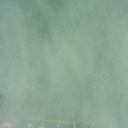
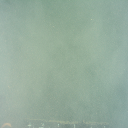
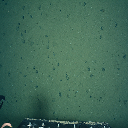
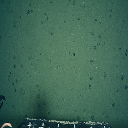
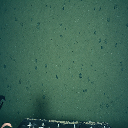
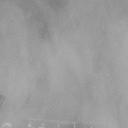
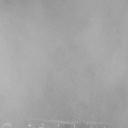
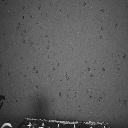
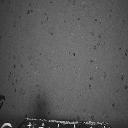
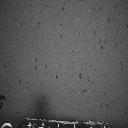
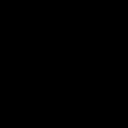
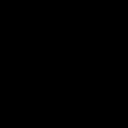
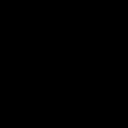
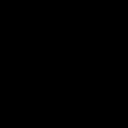
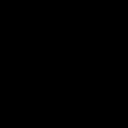

In [22]:
# See the images output
pipeline.images